In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

In [2]:
load_dotenv()
model = ChatOpenAI()

In [3]:
class BlogState(TypedDict):
    title: str
    outline: str
    content : str
    evaluate: str
    score: str

In [4]:
def create_outline(state:BlogState)-> BlogState:
    #fetch title
    title = state['title']
    
    #call LLM to generate outline
    prompt = f'Generate a detailed blog outline for a blog on the topic - {title}'
    answer = model.invoke(prompt).content
    
    #update state
    state['outline'] = answer
    
    return state

In [ ]:
def create_blog(state:BlogState)-> BlogState:
    #fetch title, outline
    title = state['title']
    outline = state['outline']
    
    #call LLM to generate outline
    prompt = f'Write a detailed blog on the topic - {title} using the given outline - {outline}'
    answer = model.invoke(prompt).content
    
    #update state
    state['content'] = answer
    
    return state

In [6]:
def evaluate_blog(state:BlogState) -> BlogState:
    #fetch title, outline, content
    title = state['title']
    outline = state['outline']
    content = state['content']
    #call LLM to generate outline
    prompt = f'Evaluate my blog - {title} {content} it was written on the outline {outline}. '
    answer = model.invoke(prompt).content
    
    #update state
    state['evaluate'] = answer
    
    return state
    

In [12]:
def generate_score(state:BlogState) -> BlogState:
    #fetch evaluate, title, content
    evaluate = state['evaluate']
    title = state['title']
    content = state['content']
    
    #call LLM to generate outline
    prompt = f'Generate a score for my blog - {title} {content} based on the given evaluation result - {evaluate}. '
    answer = model.invoke(prompt).content
    
    #update state
    state['score'] = answer
    
    return state
    

In [14]:
graph = StateGraph(BlogState)

#nodes
graph.add_node('outline',create_outline)
graph.add_node('blog',create_blog)
graph.add_node('evaluate',evaluate_blog)
graph.add_node('score',generate_score)

#edges
graph.add_edge(START,'outline')
graph.add_edge('outline','blog')
graph.add_edge('blog','evaluate')
graph.add_edge('evaluate','score')
graph.add_edge('score',END)

#compile
workflow = graph.compile()


In [16]:
input_state=  {
    'title': 'My first love'
}
output_state = workflow.invoke(input_state)

print(output_state['outline'])
print(output_state['content'])
print(output_state['evaluate'])
print(output_state['score'])

I. Introduction
   A. Explanation of what first love means 
   B. Personal experience with first love
   
II. What is first love?
   A. Definition of first love
   B. Different perspectives on first love
   C. Importance of first love in one's life
   
III. My first love story
   A. How I met my first love 
   B. The initial feelings and emotions 
   C. The evolution of the relationship 
   D. Challenges faced in the relationship 
   E. Lessons learned from my first love
   
IV. Impact of first love on my life
   A. How my first love changed me 
   B. What I learned about myself 
   C. How it shaped my future relationships 
   D. Reflection on the positive and negative effects of first love
   
V. Coping with the end of first love
   A. Dealing with heartbreak 
   B. Moving on from first love 
   C. Finding closure 
   D. Healing and self-care after first love
   
VI. Advice for others experiencing first love
    A. Tips for navigating relationships in early stages
    B. How to cope w

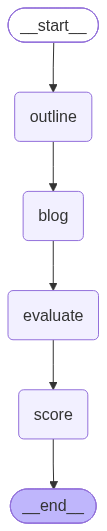

In [17]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())